In [1]:
%pip install catppuccin

In [2]:
import keras
import catppuccin
import matplotlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])


In [3]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
path

Using Colab cache for faster access to the 'intel-image-classification' dataset.


'/kaggle/input/intel-image-classification'

In [4]:
train_data = keras.utils.image_dataset_from_directory(
    directory=path + "/seg_train/seg_train",
    labels="inferred",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
)


Found 14034 files belonging to 6 classes.


In [5]:
val_data = keras.utils.image_dataset_from_directory(
    directory=path + "/seg_test/seg_test",
    labels="inferred",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
)


Found 3000 files belonging to 6 classes.


In [6]:
n = len(train_data.class_names)
n


6

In [7]:
from keras.layers import Rescaling, RandomRotation, RandomFlip, RandomZoom

data_augmentation = keras.Sequential(
    [
        RandomRotation(0.15),
        RandomFlip("horizontal"),
        RandomZoom(0.15),
    ]
)

In [8]:
from keras.applications.resnet_v2 import ResNet50V2, preprocess_input

base_model = ResNet50V2(
    include_top=True,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg",
)
base_model.trainable = False

In [9]:
from keras.layers import Dense, Input, Lambda

model = keras.Sequential(
    [
        Input(shape=(224, 224, 3)),
        data_augmentation,
        keras.layers.Lambda(preprocess_input),
        base_model,
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(n, activation="softmax"),
    ]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 1000)           │    25,613,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,750,574 (98.23 MB)

 Trainable params: 136,774 (534.27 KB)

 Non-trainable params: 25,613,800 (97.71 MB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [11]:
history = model.fit(train_data, epochs=5, validation_data=val_data)


Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 76s 148ms/step - accuracy: 0.6647 - loss: 0.9329 - val_accuracy: 0.7333 - val_loss: 0.6344
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 61s 138ms/step - accuracy: 0.7299 - loss: 0.6865 - val_accuracy: 0.7447 - val_loss: 0.6046
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 60s 138ms/step - accuracy: 0.7393 - loss: 0.6506 - val_accuracy: 0.7637 - val_loss: 0.5755
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 61s 139ms/step - accuracy: 0.7468 - loss: 0.6270 - val_accuracy: 0.7647 - val_loss: 0.5639
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 61s 139ms/step - accuracy: 0.7526 - loss: 0.6128 - val_accuracy: 0.7737 - val_loss: 0.5643


[]

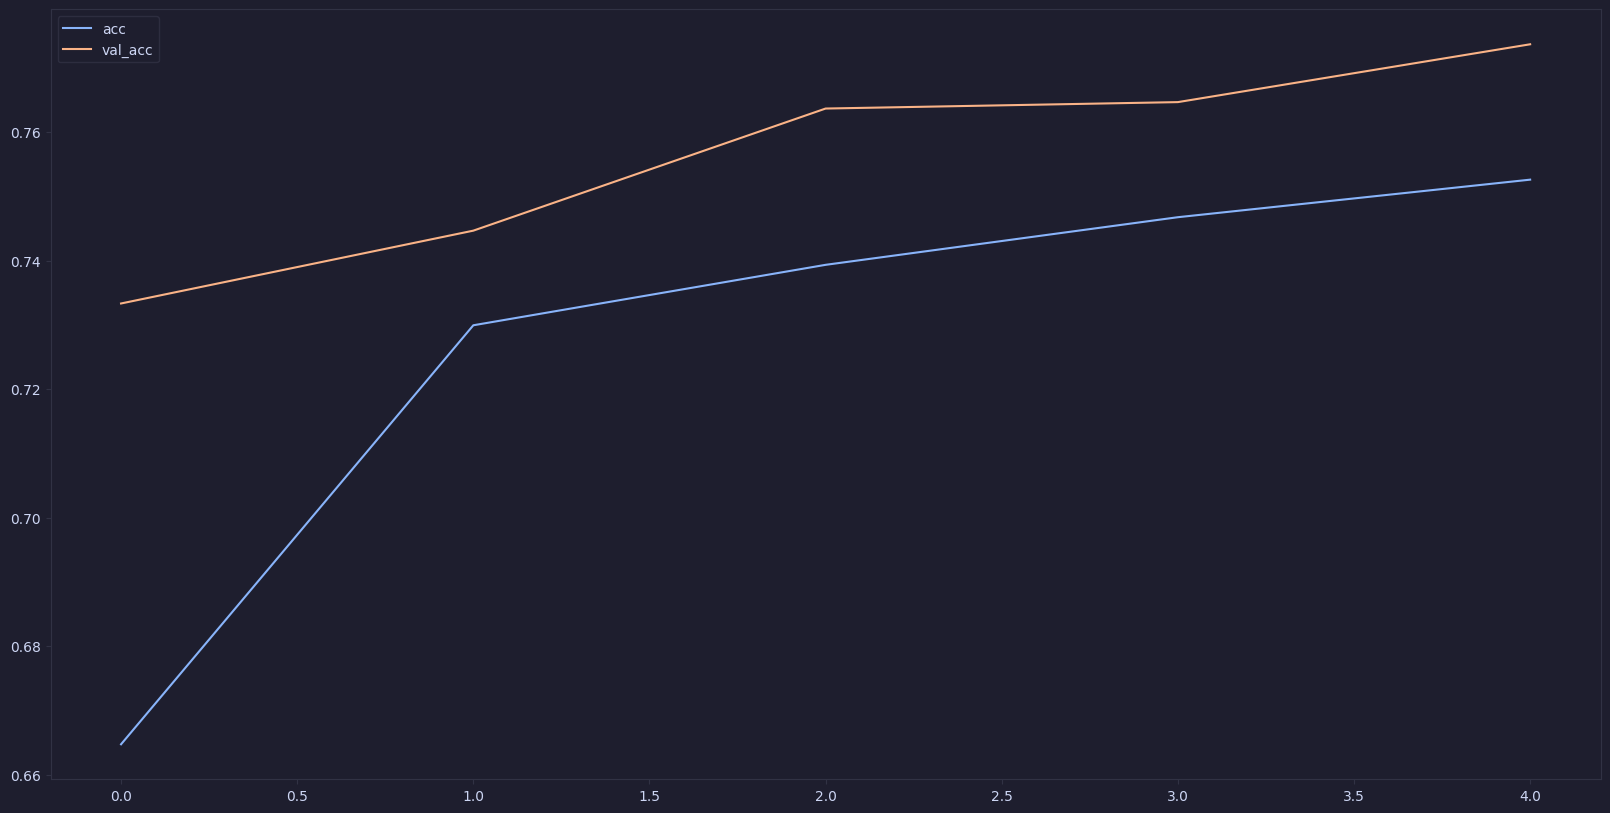

In [12]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]


plt.figure(figsize=(20, 10))
plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.legend()
plt.plot()


[]

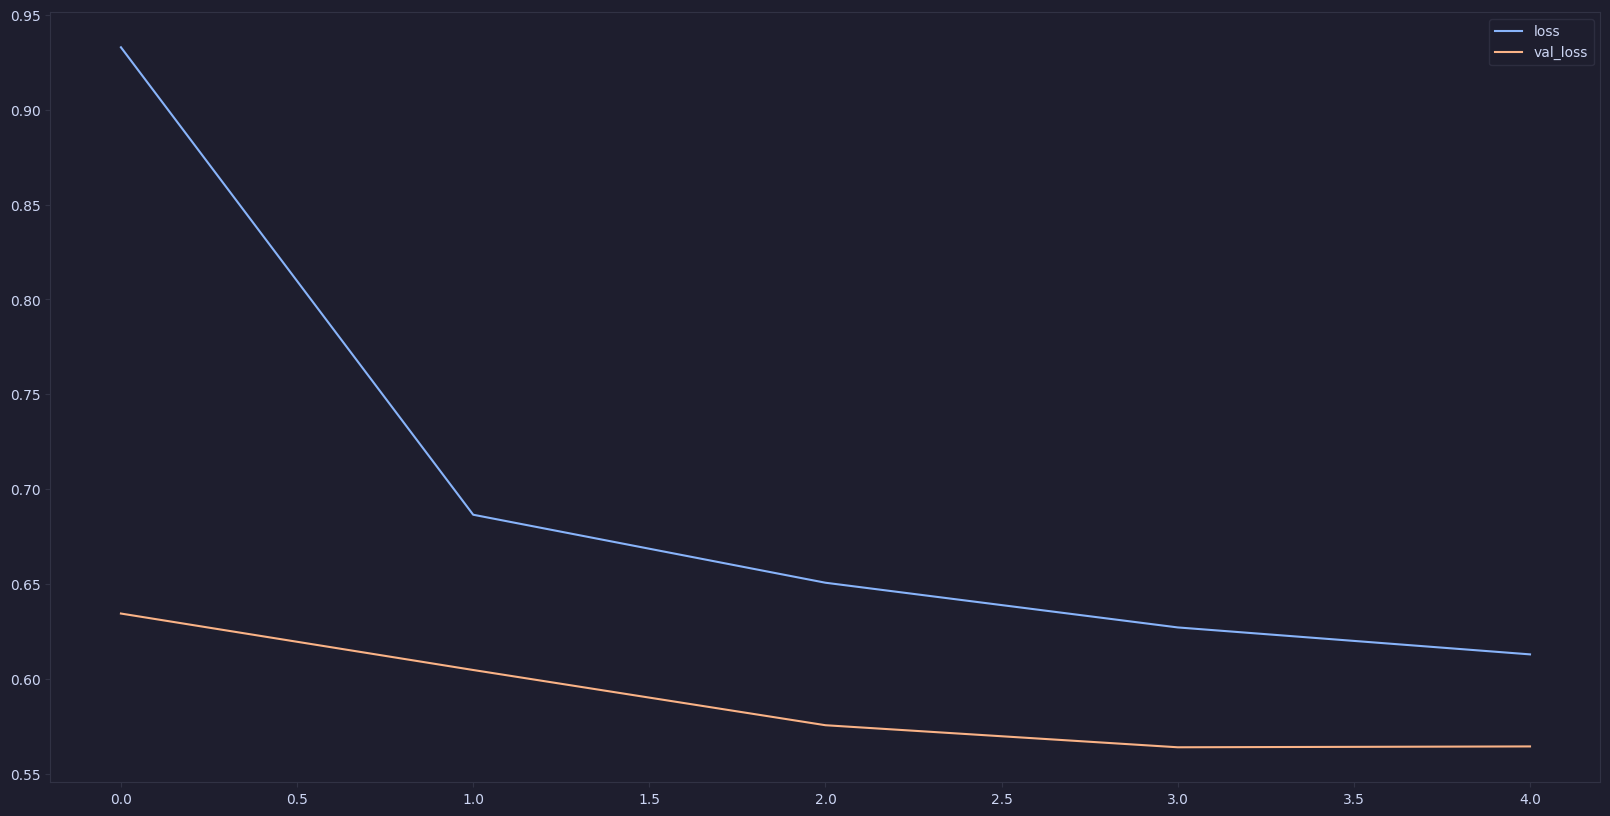

In [13]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.figure(figsize=(20, 10))
plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.legend()
plt.plot()